In [28]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, LearningCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("reduced.csv")

data = data[data['text'].notna()]
data = data[data['label'].notna()]

print("Size of dataset: ", len(data))

Size of dataset:  22975


KNN, Count Vectorization

In [29]:
# splitting

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

print("Size of training set: ", len(X_train))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = Y_train.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = Y_test.value_counts()
print(statistics)


Size of training set:  18380
Size of test set:  4595
Training set classes distribution: 
label
romance       5970
fantasy       5663
history       2158
thriller      1177
crime          856
psychology     718
science        657
horror         654
travel         320
sports         207
Name: count, dtype: int64
Test set classes distribution:
label
romance       1493
fantasy       1416
history        539
thriller       294
crime          214
psychology     180
science        164
horror         163
travel          80
sports          52
Name: count, dtype: int64


In [30]:
# vectorization & hyperparameter tuning - in this case, number of neighbors

count_vectorizer = CountVectorizer()

X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)

knn_model = KNeighborsClassifier()

parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform']
}

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")


Best score: 0.4050
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 56, 'weights': 'uniform'}


In [31]:
# results of the best parameters on test set

best_params = grid_search.best_params_

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

print(f"Accuracy on test set: ",knn_model.score(X_test, Y_test))

Accuracy on test set:  0.43046789989118606


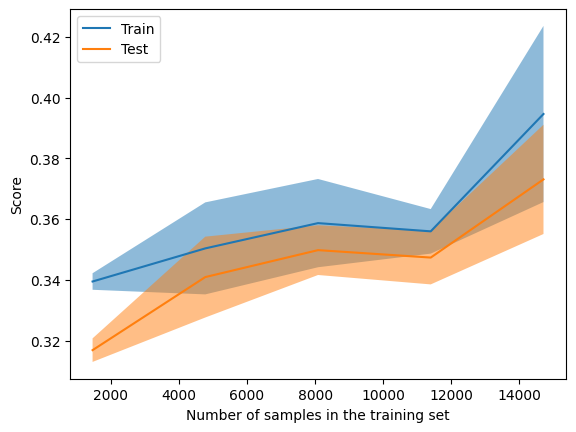

In [32]:
# learning curve for optimal number of neighbors

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=best_params["n_neighbors"])
cv = CountVectorizer()
X_train = cv.fit_transform(X_train)
LearningCurveDisplay.from_estimator(knn_model, X_train, Y_train)
plt.show()

In [33]:
target_genres = ['history', 'thriller', 'romance', 'fantasy', 'crime','science', 'psychology','travel','sports','horror']

def plot_confusion_matrix(Y, Y_pred, title, target_labels):
    matrix = metrics.confusion_matrix(Y, Y_pred, labels=target_labels)
    matrix_df = pd.DataFrame(matrix, columns=np.unique(target_labels), index=np.unique(target_labels))
    f, ax = plt.subplots(figsize=(10,5))
    ax = sns.heatmap(matrix_df, annot=True, fmt="g", cmap = "OrRd")

    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Real values")
    ax.xaxis.set_ticklabels(target_genres)
    ax.yaxis.set_ticklabels(target_genres)
    
    plt.title(title)
    plt.show()

Accuracy:  0.3338411316648531


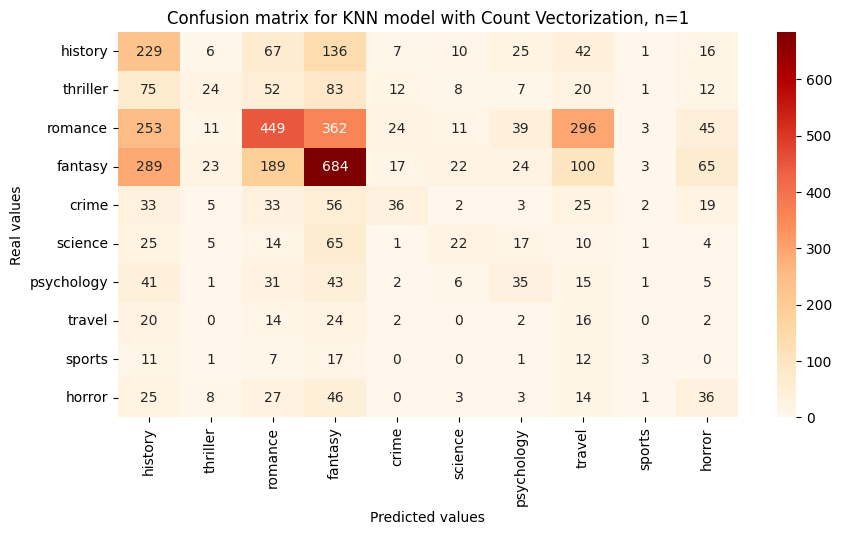

Accuracy:  0.40565832426550597


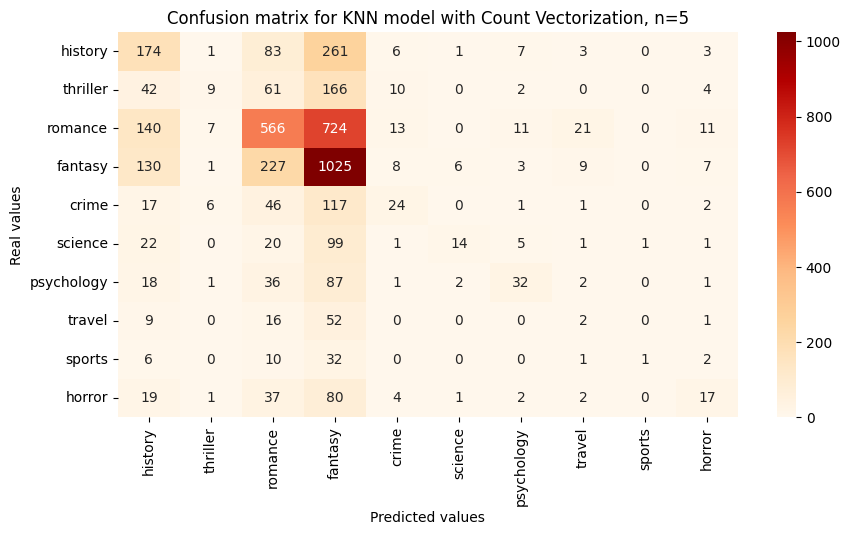

Accuracy:  0.4041349292709467


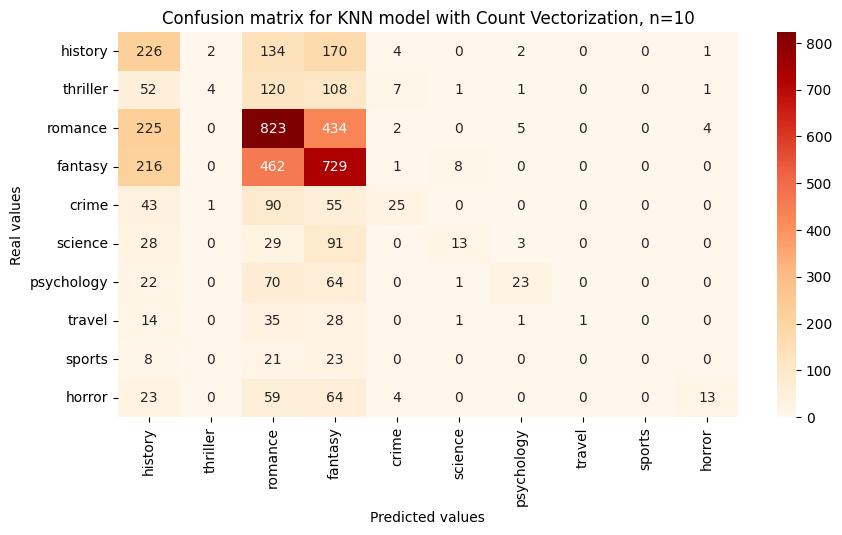

Accuracy:  0.3880304678998912


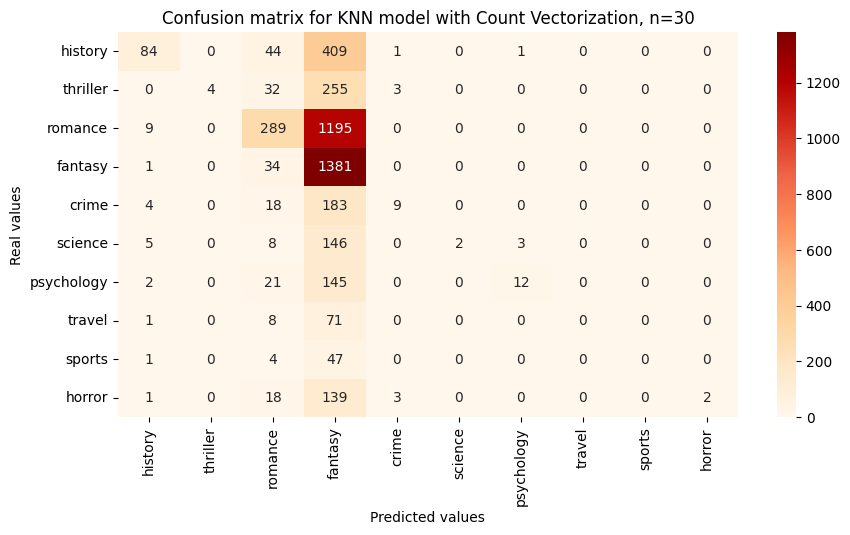

In [34]:
# confusion matrices across models with different parameters

count_vectorizer = CountVectorizer()

# 1 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=1)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=1", target_genres)

# 5 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=5)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=5", target_genres)



# 10 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=10)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=10", target_genres)

# 30 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=30)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))


plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=30", target_genres)

KNN with TFIDF Vectorizer

In [35]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer(max_df=0.95)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()

parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform', 'distance']
}

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

print(f"Accuracy on test set: ",knn_model.score(X_test, Y_test))


Best score: 0.6346
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}
Accuracy on test set:  0.634221980413493


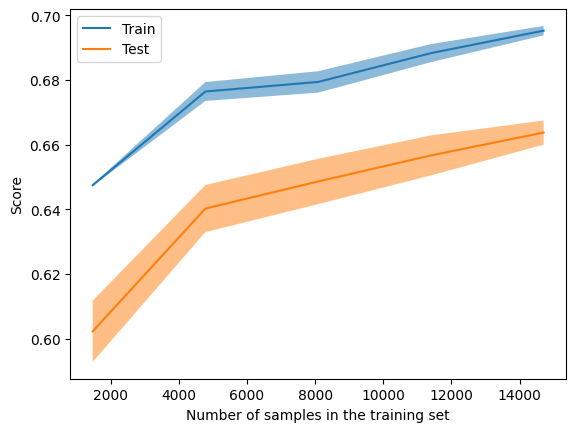

In [36]:
# learning curves for best parameter for the KNN model

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=best_params["n_neighbors"])
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train)

LearningCurveDisplay.from_estimator(knn_model,X_train,Y_train)

plt.show()

Accuracy:  0.5828073993471165


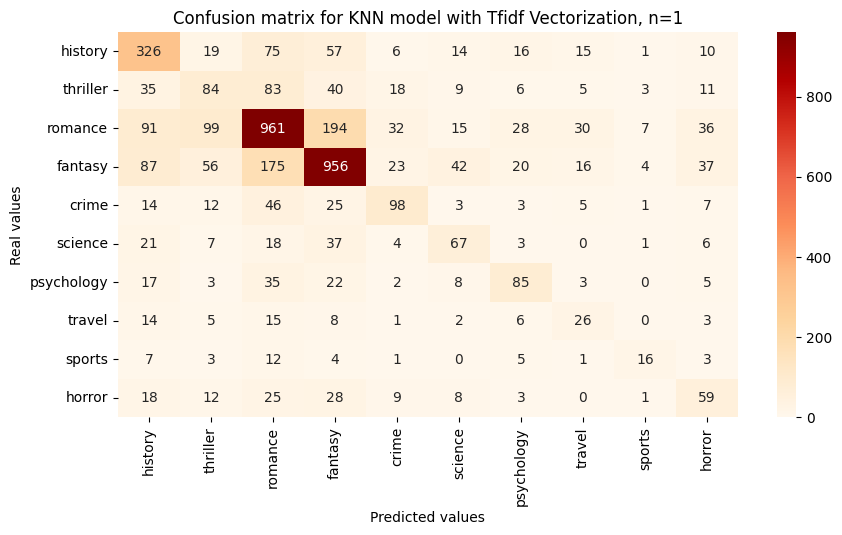

Accuracy:  0.6304678998911861


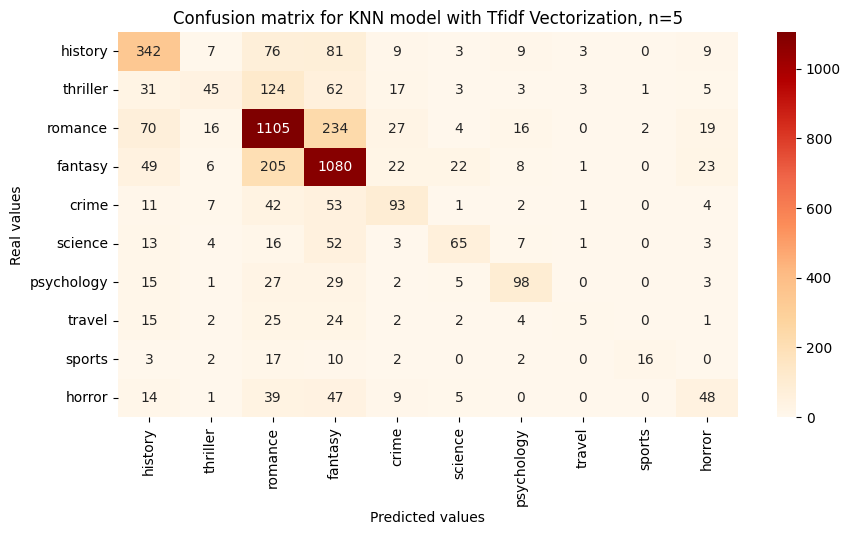

Accuracy:  0.652013057671382


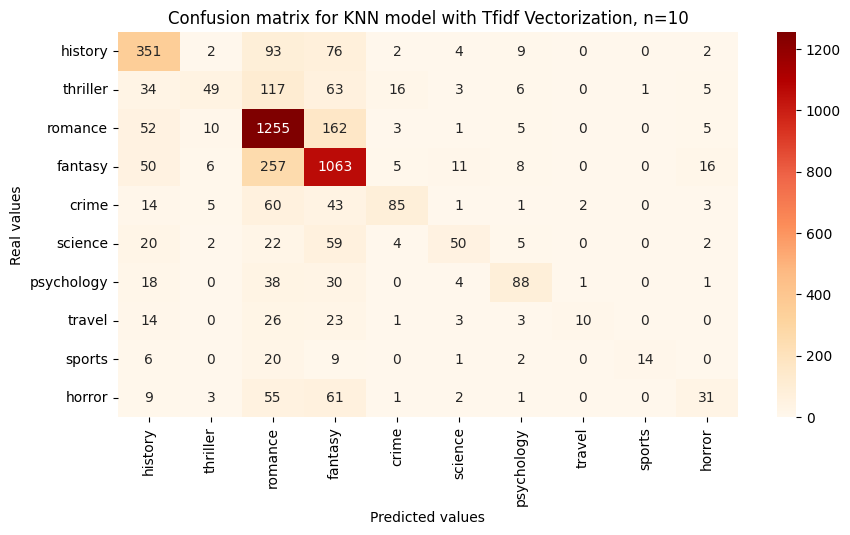

Accuracy:  0.6563656147986943


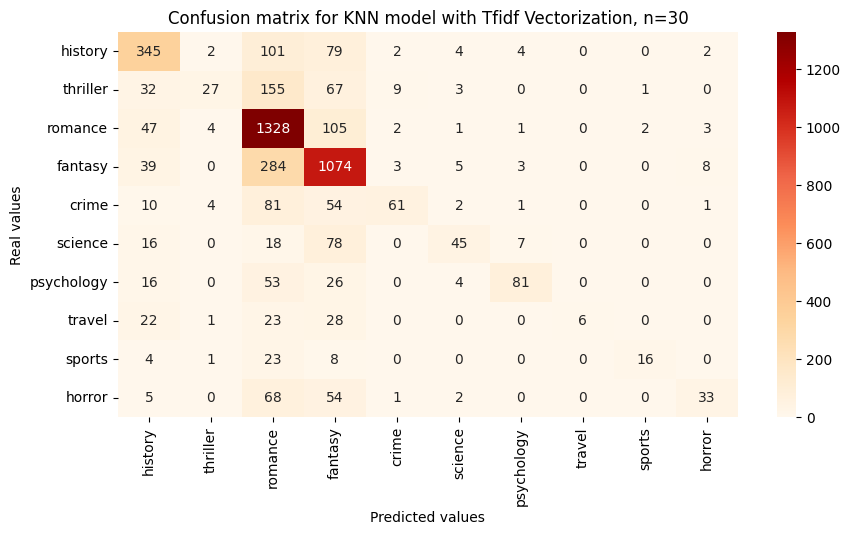

Accuracy:  0.6657236126224156


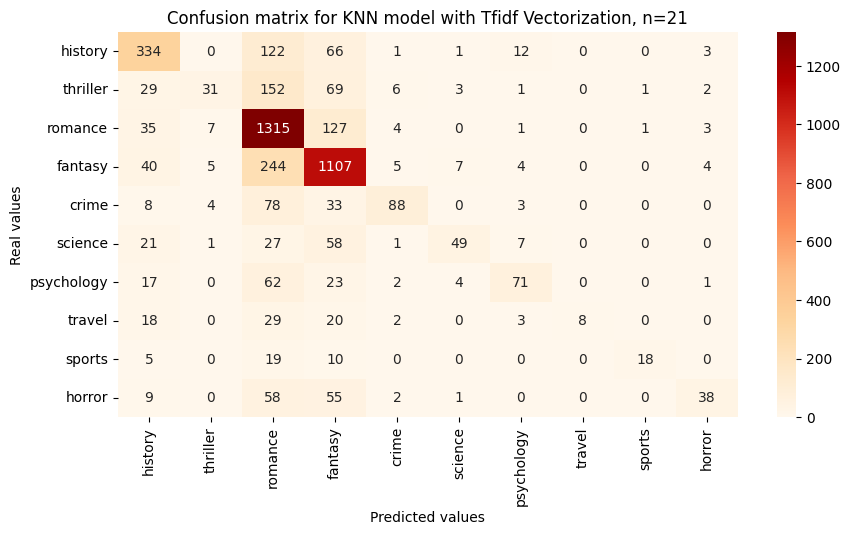

In [37]:
tfidf_vectorizer = TfidfVectorizer()

# 1 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=1)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=1", target_genres)

# 5 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=5)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=5", target_genres)

# 10 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=10)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=10", target_genres)

# 30 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=30)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=30", target_genres)

# 21 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=21)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=21", target_genres)
